# Exploring Financial Literacy and Stock Market Participation of Teacher Candidates

## 1. Import Survey Data and Libraries

In [1]:
# data handling and cleaning
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# linear and logistic regression
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.axisbelow'] = True

## 3. Load data

In [25]:
# analysis data
df = pd.read_csv("analysis_data.csv", encoding="latin-1")

## 4. Exploratory Data Analysis

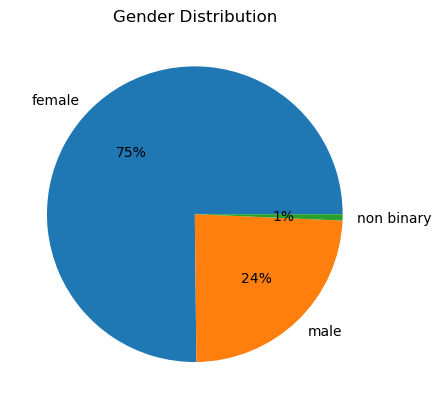

In [21]:
gender_counts = df["gender"].value_counts()

gender_counts.plot(
    kind="pie",
    autopct="%1.0f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

In [28]:
# Tables
df_mf = df[df["gender"].isin(["male", "female", "non binary"])]
summary_gender = (
    df_mf
    .groupby("gender")
    .agg(
        n_obs=("stock_mkt_participation_clean", "count"),
        n_yes=("stock_mkt_participation_clean", "sum"),
        participation_rate=("stock_mkt_participation_clean", "mean")
    )
)

# Convert to percentages
summary_gender["participation_rate"] *= 100
summary_gender = summary_gender.round(2)
summary_gender
summary_gender["n_no"] = (
    summary_gender["n_obs"] - summary_gender["n_yes"]
)

summary_gender = summary_gender[["n_obs", "n_yes", "n_no", "participation_rate"]]
summary_gender

,n_obs,n_yes,n_no,participation_rate
gender,,,,
female,109,41,68,37.61
male,35,20,15,57.14
non binary,1,0,1,0.00


In [30]:
summary_undergrad = (
    df
    .groupby("undergrad_category")
    .agg(
        n_obs=("stock_mkt_participation_clean", "count"),
        n_yes=("stock_mkt_participation_clean", "sum"),
        participation_rate=("stock_mkt_participation_clean", "mean")
    )
)

summary_undergrad["participation_rate"] *= 100
summary_undergrad = summary_undergrad.round(2)

summary_undergrad["n_no"] = (
    summary_undergrad["n_obs"] - summary_undergrad["n_yes"]
)

summary_undergrad = summary_undergrad[
    ["n_obs", "n_yes", "n_no", "participation_rate"]
]

summary_undergrad

,n_obs,n_yes,n_no,participation_rate
undergrad_category,,,,
"arts, design & media",20,8,12,40.00
education & child studies,27,8,19,29.63
humanities & languages,18,9,9,50.00
social sciences,37,14,23,37.84
stem & health sciences,43,22,21,51.16


In [32]:
summary_country = (
    df
    .groupby("born_in_canada")
    .agg(
        n_obs=("stock_mkt_participation_clean", "count"),
        n_yes=("stock_mkt_participation_clean", "sum"),
        participation_rate=("stock_mkt_participation_clean", "mean")
    )
)

summary_country["participation_rate"] *= 100
summary_country = summary_country.round(2)

# Make labels readable
summary_country.index = summary_country.index.map(
    {1: "Born in Canada", 0: "Born Outside Canada"}
)

summary_country


,n_obs,n_yes,participation_rate
born_in_canada,,,
Born Outside Canada,42,13,30.95
Born in Canada,103,48,46.60


In [34]:
summary_scores_binary = (
    df
    .groupby("stock_mkt_participation_clean")
    .agg(
        n_obs=("ID", "count"),
        avg_basic=("basic_index", "mean"),
        avg_advanced=("advanced_index", "mean"),
        avg_overall=("overall_index", "mean")
    )
    .round(2)
)
summary_scores_binary.index = summary_scores_binary.index.map(
    {1: "Participates in Stock Market", 0: "Does Not Participate / Refusal"}
)

summary_scores_binary


,n_obs,avg_basic,avg_advanced,avg_overall
stock_mkt_participation_clean,,,,
Does Not Participate / Refusal,84,0.64,0.50,0.56
Participates in Stock Market,61,0.73,0.57,0.64


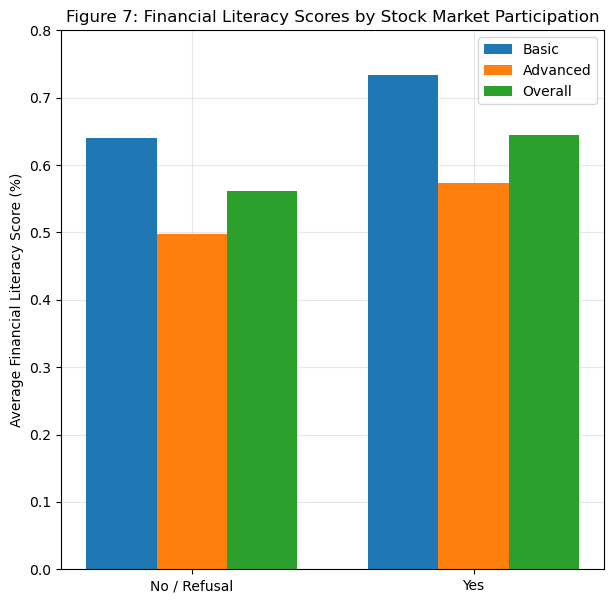

In [63]:
means = (
    df
    .groupby("stock_mkt_participation_clean")[["basic_index", "advanced_index", "overall_index"]]
    .mean()
)
means.index = ["No / Refusal", "Yes"]

labels = means.index
x = np.arange(len(labels))  # 0, 1
width = 0.25

plt.figure(figsize=(7, 7))

plt.bar(x - width, means["basic_index"], width, label="Basic")
plt.bar(x, means["advanced_index"], width, label="Advanced")
plt.bar(x + width, means["overall_index"], width, label="Overall")

plt.xticks(x, labels)
plt.ylabel("Average Financial Literacy Score (%)")
plt.title("Figure 7: Financial Literacy Scores by Stock Market Participation")

plt.ylim(0, 0.8)
plt.legend()
plt.savefig('Figure7.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Question overview

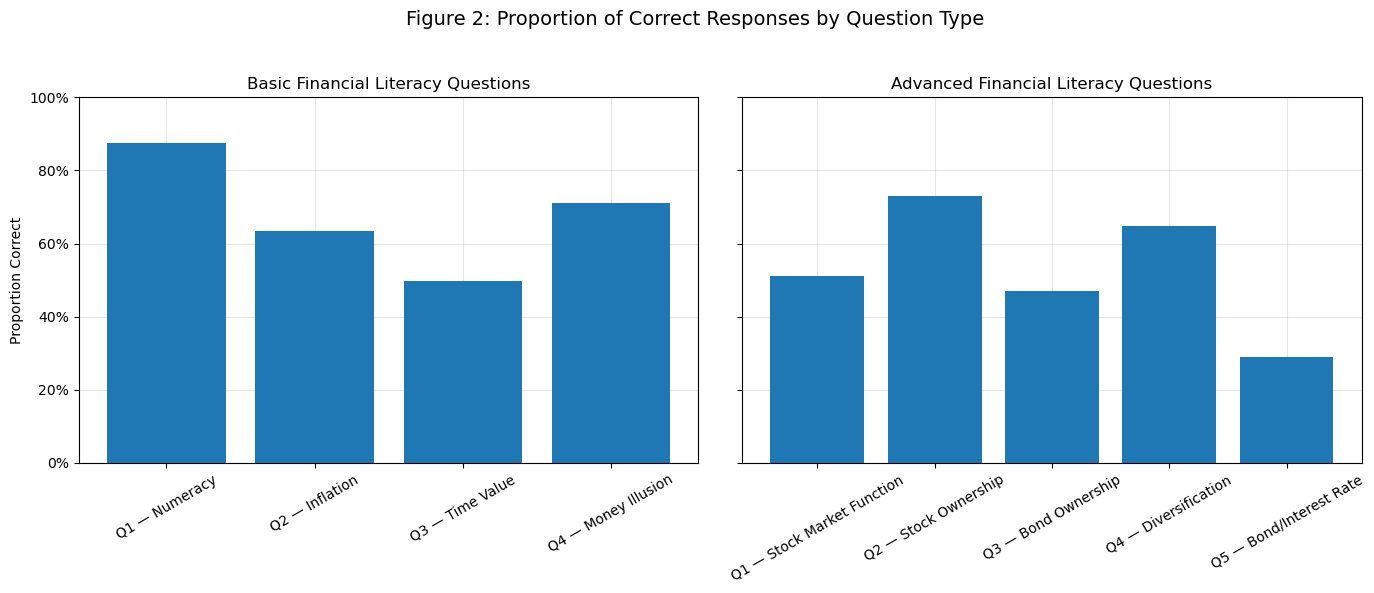

In [38]:
# Define questions
basic_questions = [
    "q1_basic_correct",
    "q2_basic_correct",
    "q3_basic_correct",
    "q4_basic_correct"
]

advanced_questions = [
    "q1_advanced_correct",
    "q2_advanced_correct",
    "q3_advanced_correct",
    "q4_advanced_correct",
    "q5_advanced_correct"
]

# Compute means
basic_means = df[basic_questions].mean()
advanced_means = df[advanced_questions].mean()

# Custom labels
basic_labels = [
    "Q1 — Numeracy",
    "Q2 — Inflation",
    "Q3 — Time Value",
    "Q4 — Money Illusion"
]

advanced_labels = [
    "Q1 — Stock Market Function",
    "Q2 — Stock Ownership",
    "Q3 — Bond Ownership",
    "Q4 — Diversification",
    "Q5 — Bond/Interest Rate"
]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Basic ---
axes[0].bar(basic_labels, basic_means)
axes[0].set_title("Basic Financial Literacy Questions")
axes[0].set_ylabel("Proportion Correct")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(lambda x, _: f"{int(x*100)}%")
axes[0].tick_params(axis='x', rotation=30)  # rotate for readability

# --- Advanced ---
axes[1].bar(advanced_labels, advanced_means)
axes[1].set_title("Advanced Financial Literacy Questions")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(lambda x, _: f"{int(x*100)}%")
axes[1].tick_params(axis='x', rotation=30)

# Figure title
fig.suptitle("Figure 2: Proportion of Correct Responses by Question Type", fontsize=14)
plt.savefig('figure2.png', dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

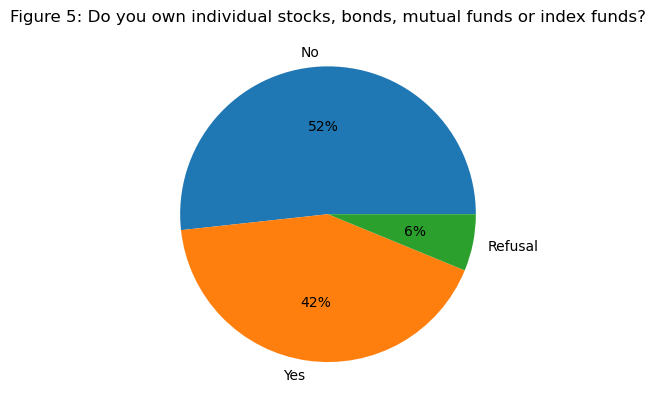

In [60]:
stock_counts = df["stock_mkt_participation"].value_counts()

stock_counts.plot(
    kind="pie",
    autopct="%1.0f%%"
)

plt.title("Figure 5: Do you own individual stocks, bonds, mutual funds or index funds?")
plt.ylabel("")
plt.savefig('figure5.png', dpi=300, bbox_inches='tight')
plt.ylabel("")
plt.show()

## 6. Additional Information

In [42]:
import seaborn as sns

In [44]:
# Filter to only male and female
df_gender = df[df['gender'].isin(['male', 'female'])]

# Group by gender and calculate mean for the three indices
mean_indices = df_gender.groupby('gender')[
    ['basic_index', 'advanced_index', 'overall_index']
].mean().round(3)  # round to 3 decimals for readability

mean_indices

,basic_index,advanced_index,overall_index
gender,,,
female,0.672,0.508,0.581
male,0.707,0.600,0.648


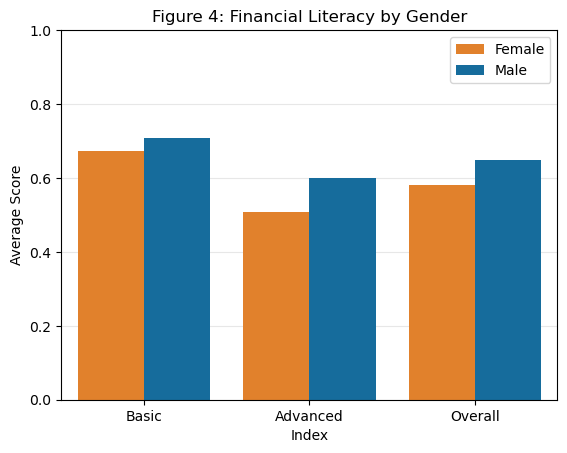

In [46]:
# Create the dataframe manually
data = {
    'gender': ['female', 'male'],
    'basic_index': [0.672, 0.707],
    'advanced_index': [0.508, 0.6],
    'overall_index': [0.581, 0.648]
}

df_manual = pd.DataFrame(data)

# Melt the dataframe
df_long = df_manual.melt(
    id_vars='gender', 
    value_vars=['basic_index', 'advanced_index', 'overall_index'],
    var_name='Index', 
    value_name='Score'
)

# Colorblind-friendly palette (Okabe–Ito)
palette = ['#FF7F0E', '#0072B2']  # blue, green
plt.xticks(
    ticks=[0, 1, 2],
    labels=["Basic", "Advanced", "Overall"]
)
# Plot
sns.barplot(x='Index', y='Score', hue='gender', data=df_long, palette=palette)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, [label.title() for label in labels], title="")
plt.title("Figure 4: Financial Literacy by Gender")
plt.ylabel("Average Score")
plt.ylim(0, 1)
plt.savefig('Figure4.png', dpi=150, bbox_inches='tight')
plt.show()

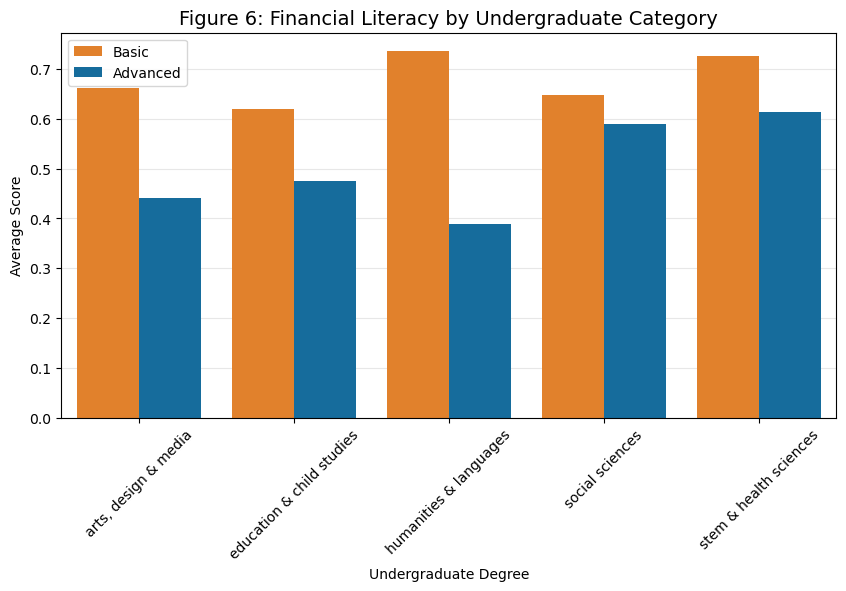

In [133]:
# Reshape data to long format
df_long = df.melt(
    id_vars='undergrad_category',
    value_vars=['basic_index', 'advanced_index'],
    var_name='Type',
    value_name='Score'
)

# Create plot
plt.figure(figsize=(10, 5))

# Colorblind-friendly palette
palette = ['#FF7F0E', '#0072B2']  # blue = basic, orange = advanced

sns.barplot(
    x='undergrad_category',
    y='Score',
    hue='Type',
    data=df_long,
    ci=None,
    palette=palette
)

# Labels and title
plt.title("Figure 6: Financial Literacy by Undergraduate Category", fontsize=14)
plt.xlabel("Undergraduate Degree")
plt.ylabel("Average Score")
plt.xticks(rotation=45)

# Clean legend labels
plt.legend(title="", labels=["Basic", "Advanced"])

# Save figure
plt.savefig('figure6.png', dpi=300, bbox_inches='tight')

plt.show()

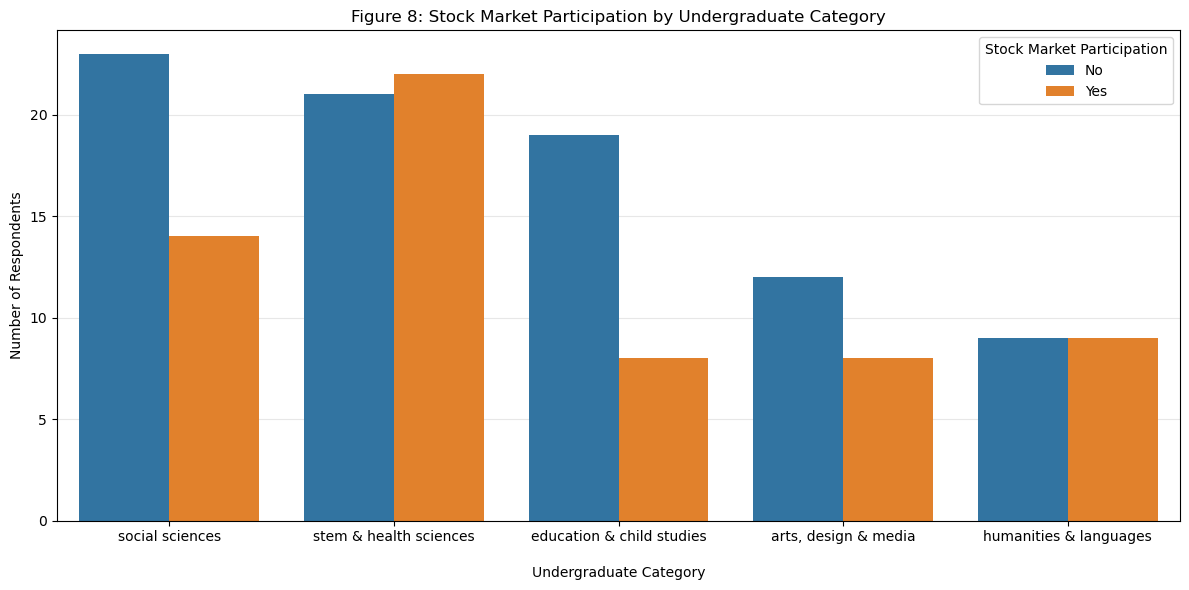

In [48]:
plt.figure(figsize=(12, 6))

sns.countplot(
    x='undergrad_category',
    hue='stock_mkt_participation_clean',  # 0 / 1
    data=df
)

plt.xlabel("\nUndergraduate Category")
plt.ylabel("Number of Respondents")
plt.title("Figure 8: Stock Market Participation by Undergraduate Category")
plt.xticks(rotation=0)

# Relabel legend: 0 = No, 1 = Yes
plt.legend(
    title="Stock Market Participation",
    labels=["No", "Yes"]
)

plt.tight_layout()
plt.savefig('Figure8.png', dpi=150, bbox_inches='tight')
plt.show()

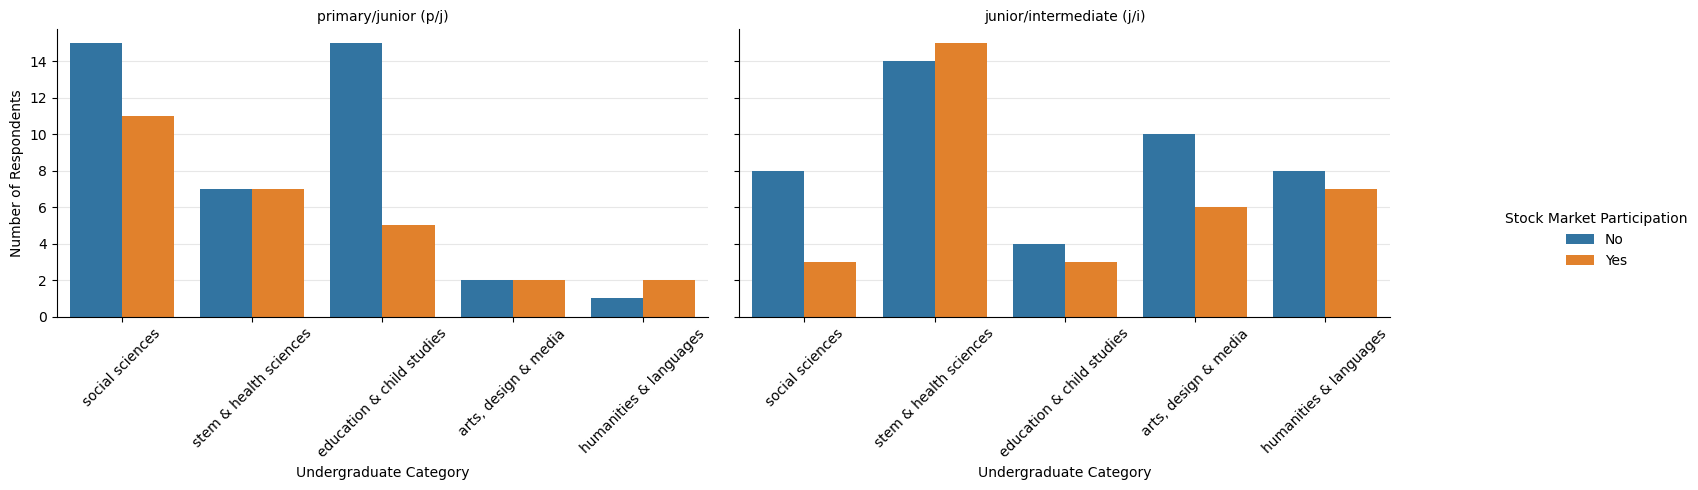

In [50]:
g = sns.catplot(
    x='undergrad_category',
    hue='stock_mkt_participation_clean',
    col='teaching_division',
    data=df,
    kind='count',
    height=5,
    aspect=1.2   # ⬅ makes each facet wider
)

g.set_axis_labels("Undergraduate Category", "Number of Respondents")
g.set_titles("{col_name}")

# Move legend outside the plots
g._legend.set_title("Stock Market Participation")
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_loc("center left")

# Relabel legend entries
for t, l in zip(g._legend.texts, ["No", "Yes"]):
    t.set_text(l)

# Rotate x labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

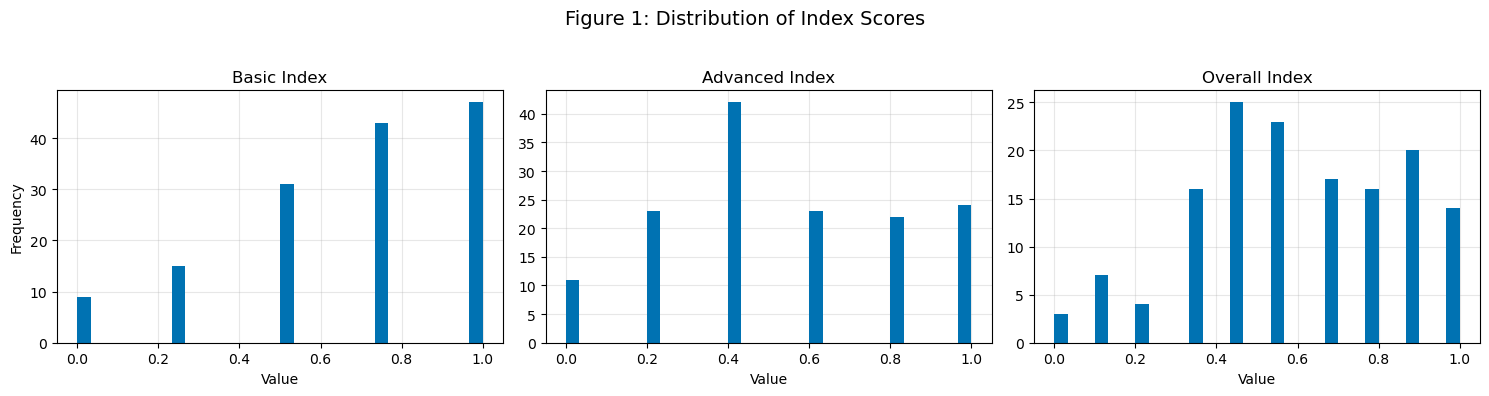

In [56]:
# Create figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Basic Index
axes[0].hist(df['basic_index'].dropna(), bins=30, color='#0072B2')
axes[0].set_title('Basic Index')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# Advanced Index
axes[1].hist(df['advanced_index'].dropna(), bins=30, color='#0072B2')
axes[1].set_title('Advanced Index')
axes[1].set_xlabel('Value')

# Overall Index
axes[2].hist(df['overall_index'].dropna(), bins=30, color='#0072B2')
axes[2].set_title('Overall Index')
axes[2].set_xlabel('Value')

# Add overall figure title
fig.suptitle('Figure 1: Distribution of Index Scores', fontsize=14)

# Adjust layout so title doesn’t overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('figure1.png', dpi=300, bbox_inches='tight')
plt.show()

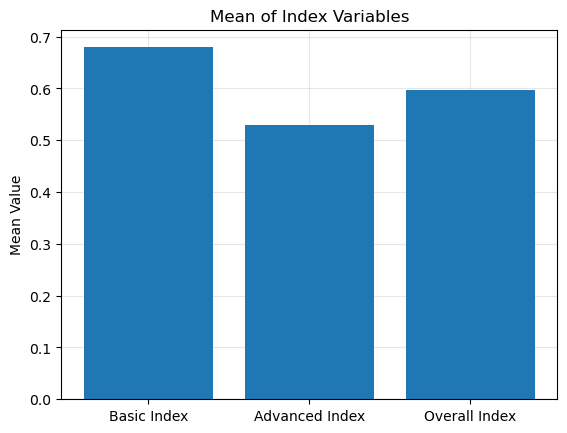

In [58]:
# Compute means (automatically ignores NaNs)
basic_mean = df['basic_index'].mean()
advanced_mean = df['advanced_index'].mean()
overall_mean = df['overall_index'].mean()

# Store for plotting
labels = ['Basic Index', 'Advanced Index', 'Overall Index']
means = [basic_mean, advanced_mean, overall_mean]

# Create bar plot
plt.figure()
plt.bar(labels, means)

plt.title('Mean of Index Variables')
plt.ylabel('Mean Value')
plt.show()

## 7. Regressions

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [21]:
# 1. DATA PREPARATION
 
# -- Clean stock market participation to binary (1 = yes, 0 = no/refusal)
df['stock_mkt_binary'] = df['stock_mkt_participation'].map(
    lambda x: 1 if str(x).strip().lower() == 'yes' else 0
)
 
# -- Gender dummies (reference category: female)
df['gender_clean'] = df['gender'].str.strip().str.lower()
 
# -- Born in Canada binary (already in dataset as born_in_canada)
# Ensure it's 0/1
df['born_in_canada_bin'] = df['born_in_canada'].map(
    lambda x: 1 if str(x).strip().lower() in ['true', 'yes', '1'] else 0
)
 
# -- Undergraduate category dummies (reference: Arts, Design & Media)
undergrad_dummies = pd.get_dummies(
    df['undergrad_category'], prefix='undergrad', drop_first=False
)
# Drop reference category manually for clean interpretation
ref_col = [c for c in undergrad_dummies.columns if 'arts' in c.lower()]
if ref_col:
    undergrad_dummies = undergrad_dummies.drop(columns=ref_col)
 
# -- Gender dummies (reference: female)
gender_dummies = pd.get_dummies(df['gender_clean'], prefix='gender', drop_first=False)
ref_gender = [c for c in gender_dummies.columns if 'female' in c.lower()]
if ref_gender:
    gender_dummies = gender_dummies.drop(columns=ref_gender)
 
# -- Combine all predictors into one dataframe
predictors = pd.concat([
    df[['age', 'duration_minutes', 'born_in_canada_bin',
        'stock_mkt_binary', 'overall_index', 'basic_index', 'advanced_index']],
    gender_dummies,
    undergrad_dummies
], axis=1).dropna()
 
print(f"Sample size after dropping missing values: {len(predictors)}")
print(f"Stock market participants: {predictors['stock_mkt_binary'].sum()}")
print(f"Non-participants: {(predictors['stock_mkt_binary'] == 0).sum()}")

Sample size after dropping missing values: 145
Stock market participants: 61
Non-participants: 84


In [25]:
# Fix data types
# Fix 1: Convert pandas nullable Float64 to standard float64
for col in ['overall_index', 'basic_index', 'advanced_index']:
    if col in predictors.columns:
        predictors[col] = predictors[col].astype(float)

# Fix 2: Convert all bool columns to int
bool_cols = predictors.select_dtypes(include='bool').columns.tolist()
print(f"Converting bool columns to int: {bool_cols}")
predictors[bool_cols] = predictors[bool_cols].astype(int)

# Verify everything is now numeric
print("\nDtypes after fix:")
print(predictors.dtypes)
print("\nAny remaining non-numeric columns:")
print(predictors.select_dtypes(exclude=[np.number]).columns.tolist())

Converting bool columns to int: ['gender_male', 'gender_non binary', 'undergrad_education & child studies', 'undergrad_humanities & languages', 'undergrad_social sciences', 'undergrad_stem & health sciences']

Dtypes after fix:
age                                      int64
duration_minutes                       float64
born_in_canada_bin                       int64
stock_mkt_binary                         int64
overall_index                          float64
basic_index                            float64
advanced_index                         float64
gender_male                              int64
gender_non binary                        int64
undergrad_education & child studies      int64
undergrad_humanities & languages         int64
undergrad_social sciences                int64
undergrad_stem & health sciences         int64
dtype: object

Any remaining non-numeric columns:
[]


In [151]:
# -- Build predictor matrix
lm_cols = (
    ['age', 'duration_minutes', 'born_in_canada_bin']
    + [c for c in gender_dummies.columns]
    + [c for c in undergrad_dummies.columns]
)
 
X_lm = predictors[lm_cols].copy()
X_lm = sm.add_constant(X_lm)  # adds intercept
y_lm = predictors['overall_index']
 
# -- Fit model
lm_model = sm.OLS(y_lm, X_lm).fit()
print(lm_model.summary())
 
# -- Save residuals and fitted values for assumption checks
residuals_lm = lm_model.resid
fitted_lm    = lm_model.fittedvalues

                            OLS Regression Results                            
Dep. Variable:          overall_index   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.022
Date:                Tue, 24 Mar 2026   Prob (F-statistic):              0.426
Time:                        18:35:46   Log-Likelihood:                -4.1362
No. Observations:                 145   AIC:                             28.27
Df Residuals:                     135   BIC:                             58.04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co


ASSUMPTION CHECKS — Linear Regression


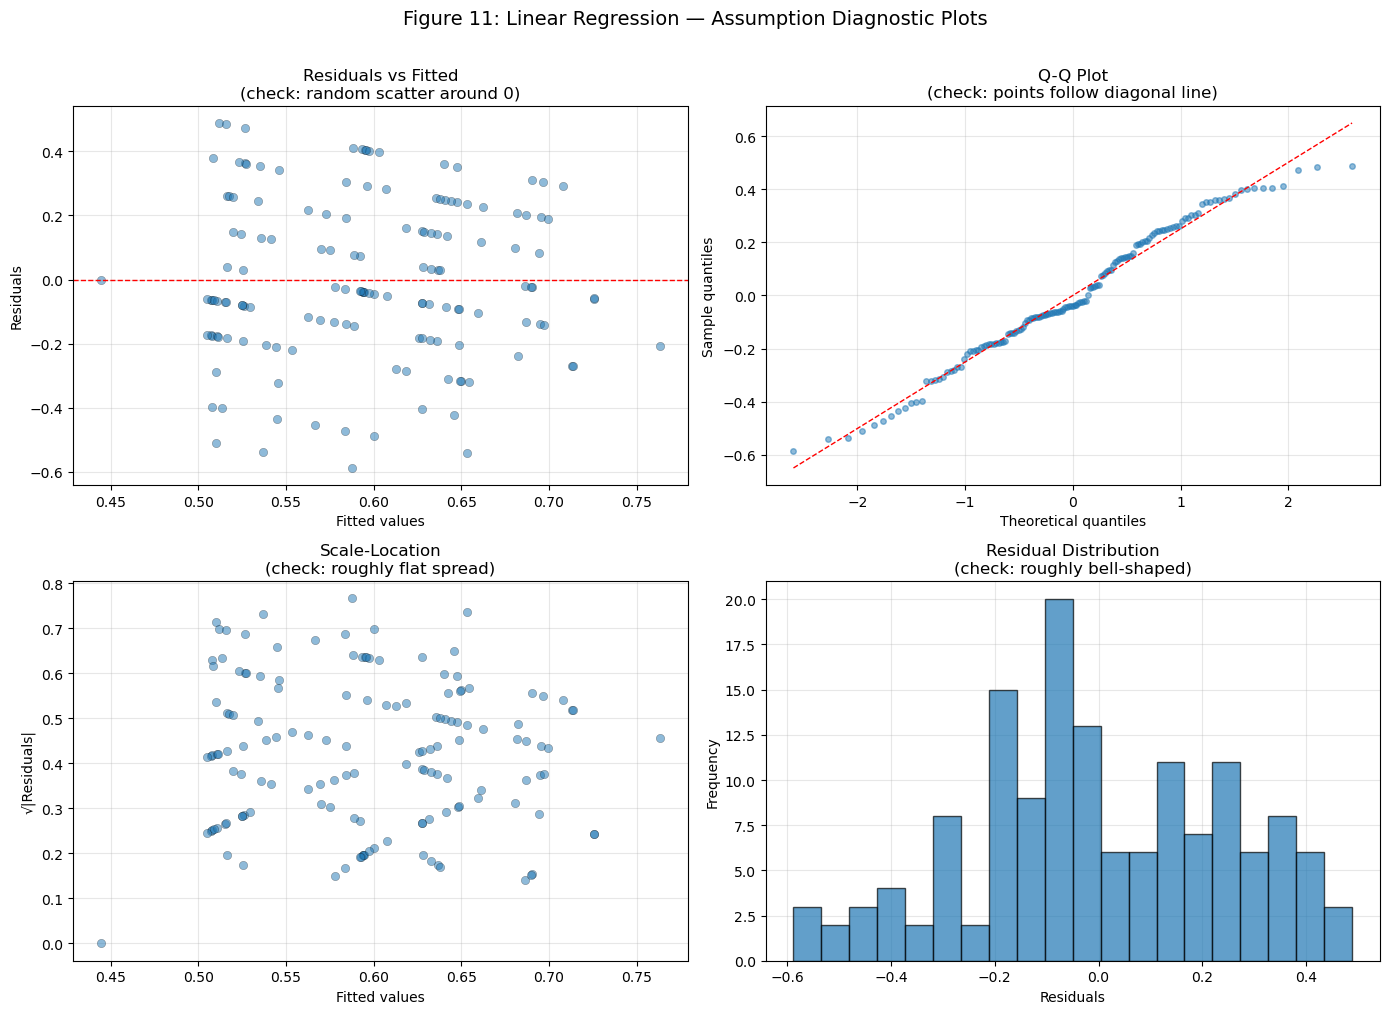

Saved: lm_assumption_plots.png

Durbin-Watson statistic: 1.695
  Interpretation: ~2.0 = no autocorrelation (good)
  → OK

Variance Inflation Factors (VIF):
  Rule of thumb: VIF < 5 = fine, 5-10 = moderate, >10 = serious
                           Variable      VIF
                                age 1.192724
                   duration_minutes 1.095765
                 born_in_canada_bin 1.114396
                        gender_male 1.046591
                  gender_non binary 1.077419
undergrad_education & child studies 1.926234
   undergrad_humanities & languages 1.758191
          undergrad_social sciences 2.157231
   undergrad_stem & health sciences 2.231985

  Max VIF: 2.23 → No multicollinearity concern

Shapiro-Wilk test on residuals: W=0.9808, p=0.0394
  → Residuals deviate from normality — flag in paper


In [143]:
print("\n" + "="*70)
print("ASSUMPTION CHECKS — Linear Regression")
print("="*70)
 
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Figure 11: Linear Regression — Assumption Diagnostic Plots', fontsize=14, y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig)
 
# -- 3a. Residuals vs Fitted (linearity + homoscedasticity)
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(fitted_lm, residuals_lm, alpha=0.5, edgecolors='k', linewidths=0.3)
ax1.axhline(0, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted\n(check: random scatter around 0)')
 
# -- 3b. Q-Q Plot (normality of residuals)
ax2 = fig.add_subplot(gs[0, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_lm, dist="norm")
ax2.plot(osm, osr, 'o', alpha=0.5, markersize=4)
ax2.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1)
ax2.set_xlabel('Theoretical quantiles')
ax2.set_ylabel('Sample quantiles')
ax2.set_title('Q-Q Plot\n(check: points follow diagonal line)')
 
# -- 3c. Scale-Location (homoscedasticity)
ax3 = fig.add_subplot(gs[1, 0])
sqrt_abs_resid = np.sqrt(np.abs(residuals_lm))
ax3.scatter(fitted_lm, sqrt_abs_resid, alpha=0.5, edgecolors='k', linewidths=0.3)
ax3.set_xlabel('Fitted values')
ax3.set_ylabel('√|Residuals|')
ax3.set_title('Scale-Location\n(check: roughly flat spread)')
 
# -- 3d. Residuals histogram
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuals_lm, bins=20, edgecolor='black', alpha=0.7)
ax4.set_xlabel('Residuals')
ax4.set_ylabel('Frequency')
ax4.set_title('Residual Distribution\n(check: roughly bell-shaped)')
 
plt.tight_layout()
plt.savefig('lm_assumption_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lm_assumption_plots.png")
 
# -- 3e. Durbin-Watson (independence of residuals)
dw_stat = durbin_watson(residuals_lm)
print(f"\nDurbin-Watson statistic: {dw_stat:.3f}")
print("  Interpretation: ~2.0 = no autocorrelation (good)")
print(f"  → {'OK' if 1.5 < dw_stat < 2.5 else 'Potential autocorrelation — flag in paper'}")
 
# -- 3f. VIF (multicollinearity)
print("\nVariance Inflation Factors (VIF):")
print(f"  Rule of thumb: VIF < 5 = fine, 5-10 = moderate, >10 = serious")
vif_data = pd.DataFrame()
vif_data['Variable'] = X_lm.columns[1:]  # exclude constant
vif_data['VIF'] = [
    variance_inflation_factor(X_lm.values, i+1)
    for i in range(len(X_lm.columns) - 1)
]
print(vif_data.to_string(index=False))
max_vif = vif_data['VIF'].max()
print(f"\n  Max VIF: {max_vif:.2f} → "
      f"{'No multicollinearity concern' if max_vif < 5 else 'Flag in paper'}")
 
# -- 3g. Shapiro-Wilk test for normality
stat_sw, p_sw = stats.shapiro(residuals_lm)
print(f"\nShapiro-Wilk test on residuals: W={stat_sw:.4f}, p={p_sw:.4f}")
print(f"  → {'Residuals approximately normal (p > 0.05)' if p_sw > 0.05 else 'Residuals deviate from normality — flag in paper'}")

In [159]:
# 4. LOGISTIC REGRESSION — RQ3
#    Outcome: stock_mkt_binary
#    Predictors: overall_index + demographics
# =============================================================================
 
print("\n" + "="*70)
print("LOGISTIC REGRESSION — Predictors of Stock Market Participation")
print("="*70)
 
# -- Build predictor matrix (same predictors, different outcome)
glm_cols = (
    ['overall_index', 'age', 'duration_minutes', 'born_in_canada_bin']
    + [c for c in gender_dummies.columns]
    + [c for c in undergrad_dummies.columns]
)
 
X_glm = predictors[glm_cols].copy()
X_glm = sm.add_constant(X_glm)
y_glm = predictors['stock_mkt_binary']
 
# -- Fit logistic regression
glm_model = sm.Logit(y_glm, X_glm).fit()
print(glm_model.summary())
 
# -- Odds ratios (easier to interpret than log-odds)
print("\nOdds Ratios (exp of coefficients):")
odds_ratios = pd.DataFrame({
    'Odds Ratio': np.exp(glm_model.params),
    '95% CI Lower': np.exp(glm_model.conf_int()[0]),
    '95% CI Upper': np.exp(glm_model.conf_int()[1]),
    'p-value': glm_model.pvalues
})
print(odds_ratios.round(3).to_string())


LOGISTIC REGRESSION — Predictors of Stock Market Participation
         Current function value: 0.626907
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:       stock_mkt_binary   No. Observations:                  145
Model:                          Logit   Df Residuals:                      134
Method:                           MLE   Df Model:                           10
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                 0.07877
Time:                        18:38:05   Log-Likelihood:                -90.902
converged:                      False   LL-Null:                       -98.674
Covariance Type:            nonrobust   LLR p-value:                    0.1134
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                         

In [41]:
# 5. ASSUMPTION CHECKS — LOGISTIC REGRESSION
# =============================================================================
 
print("\n" + "="*70)
print("ASSUMPTION CHECKS — Logistic Regression")
print("="*70)
 
# -- 5a. Sample size adequacy (10 events per predictor rule)
n_events    = int(y_glm.sum())
n_predictors = X_glm.shape[1] - 1  # exclude constant
min_required = n_predictors * 10
print(f"\nSample size adequacy (Peduzzi et al., 1996 rule):")
print(f"  Events (investors): {n_events}")
print(f"  Number of predictors: {n_predictors}")
print(f"  Minimum events required (10 per predictor): {min_required}")
print(f"  → {'Threshold met' if n_events >= min_required else 'Below threshold — flag in paper as limitation'}")
 
# -- 5b. VIF for logistic regression
print("\nVariance Inflation Factors (Logistic Regression):")
vif_glm = pd.DataFrame()
vif_glm['Variable'] = X_glm.columns[1:]
vif_glm['VIF'] = [
    variance_inflation_factor(X_glm.values, i+1)
    for i in range(len(X_glm.columns) - 1)
]
print(vif_glm.to_string(index=False))
max_vif_glm = vif_glm['VIF'].max()
print(f"\n  Max VIF: {max_vif_glm:.2f} → "
      f"{'No multicollinearity concern' if max_vif_glm < 5 else 'Flag in paper'}")
 
# -- 5c. Linearity of log-odds for continuous predictors (Box-Tidwell approach)
#    For each continuous predictor, add an interaction term x*log(x)
#    Non-significant interaction = linearity assumption holds
print("\nBox-Tidwell test (linearity of log-odds for continuous predictors):")
print("  Non-significant p-value = linearity assumption holds for that predictor")
 
continuous_vars = ['overall_index', 'age', 'duration_minutes']
bt_data = predictors[continuous_vars + ['stock_mkt_binary']].dropna().copy()
 
for var in continuous_vars:
    # Shift to avoid log(0) — add small constant if needed
    bt_data[f'{var}_log'] = np.log(bt_data[var].clip(lower=0.001))
    bt_data[f'{var}_interaction'] = bt_data[var] * bt_data[f'{var}_log']
 
bt_X = bt_data[
    continuous_vars + [f'{v}_interaction' for v in continuous_vars]
].copy()
bt_X = sm.add_constant(bt_X)
bt_y = bt_data['stock_mkt_binary']
 
bt_model = sm.Logit(bt_y, bt_X).fit(disp=0)
 
for var in continuous_vars:
    coef = bt_model.params.get(f'{var}_interaction', np.nan)
    pval = bt_model.pvalues.get(f'{var}_interaction', np.nan)
    result = 'Linearity holds' if pval > 0.05 else 'Non-linear — flag in paper'
    print(f"  {var}: interaction coef={coef:.4f}, p={pval:.4f} → {result}")


ASSUMPTION CHECKS — Logistic Regression

Sample size adequacy (Peduzzi et al., 1996 rule):
  Events (investors): 61
  Number of predictors: 10
  Minimum events required (10 per predictor): 100
  → Below threshold — flag in paper as limitation

Variance Inflation Factors (Logistic Regression):
                           Variable      VIF
                      overall_index 1.068110
                                age 1.200329
                   duration_minutes 1.096023
                 born_in_canada_bin 1.114736
                        gender_male 1.055446
                  gender_non binary 1.078033
undergrad_education & child studies 1.926254
   undergrad_humanities & languages 1.758243
          undergrad_social sciences 2.173840
   undergrad_stem & health sciences 2.278127

  Max VIF: 2.28 → No multicollinearity concern

Box-Tidwell test (linearity of log-odds for continuous predictors):
  Non-significant p-value = linearity assumption holds for that predictor
  overall_index: in

## 8. Final visualizations

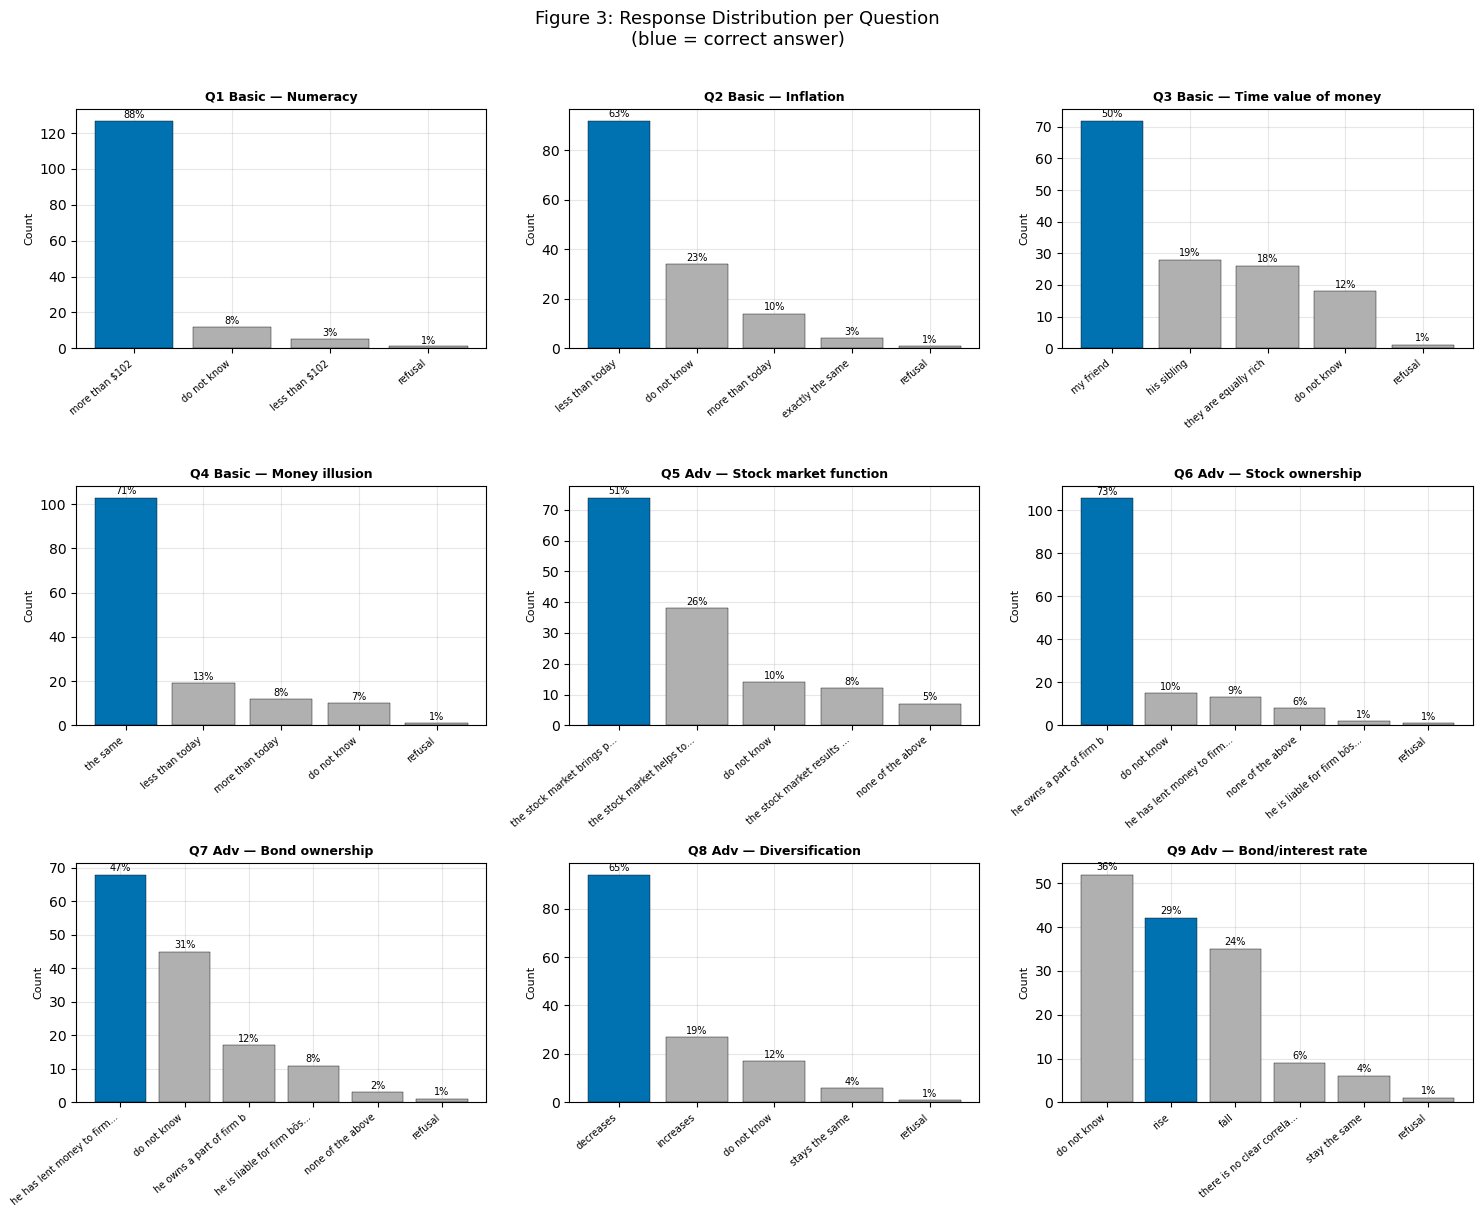

Saved: response_histograms.png


In [55]:
# =============================================================================
# RESPONSE DISTRIBUTION — One histogram per question
# =============================================================================
# Color before: #4C9BE8
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

questions = {
    'q1_basic':    'Q1 Basic — Numeracy',
    'q2_basic':    'Q2 Basic — Inflation',
    'q3_basic':    'Q3 Basic — Time value of money',
    'q4_basic':    'Q4 Basic — Money illusion',
    'q1_advanced': 'Q5 Adv — Stock market function',
    'q2_advanced': 'Q6 Adv — Stock ownership',
    'q3_advanced': 'Q7 Adv — Bond ownership',
    'q4_advanced': 'Q8 Adv — Diversification',
    'q5_advanced': 'Q9 Adv — Bond/interest rate',
}

correct_answers = {
    'q1_basic':    'more than $102',   # adjust to match your exact strings
    'q2_basic':    'less than today',
    'q3_basic':    'my friend',
    'q4_basic':    'the same',
    'q1_advanced': 'the stock market brings people who want to buy stocks together with those who want to sell stocks.',
    'q2_advanced': 'he owns a part of firm b',
    'q3_advanced': 'he has lent money to firm b',
    'q4_advanced': 'decreases',
    'q5_advanced': 'rise',
}

for i, (col, title) in enumerate(questions.items()):
    ax = axes[i]
    
    # Get value counts and shorten long labels
    counts = df[col].value_counts(dropna=False)
    
    # Shorten labels for readability
    short_labels = []
    for label in counts.index:
        s = str(label)
        short_labels.append(s[:25] + '...' if len(s) > 25 else s)
    
    # Color bars — green for correct answer, gray for others
    correct = correct_answers.get(col, )
    colors = [
        '#0072B2' if str(label) == correct else '#B0B0B0'
        for label in counts.index
    ]
    
    bars = ax.bar(range(len(counts)), counts.values, color=colors, edgecolor='black', linewidth=0.3)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=7)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylabel('Count', fontsize=8)
    
    # Add percentage labels on top of bars
    total = counts.values.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{100*val/total:.0f}%', ha='center', va='bottom', fontsize=7)

# Hide the 9th subplot if only 9 questions (3x3 = 9, fits perfectly)
fig.suptitle('Figure 3: Response Distribution per Question\n(blue = correct answer)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('Figure3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: response_histograms.png")

In [65]:
# Summary table printed in notebook
print("\nResponse Distribution Summary:")
print(f"{'Question':<45} {'Correct':>10} {'Incorrect':>10} {'Do not know':>12}")
print("-" * 80)

for col, title in questions.items():
    counts    = df[col].value_counts(dropna=False)
    total     = counts.values.sum()
    correct_answer = correct_answers.get(col, '').strip().lower()

    n_correct   = sum(v for k, v in counts.items() 
                      if str(k).strip().lower() == correct_answer)
    n_dnk       = sum(v for k, v in counts.items() 
                      if 'not know' in str(k).strip().lower())
    n_refusal   = sum(v for k, v in counts.items() 
                      if 'refusal' in str(k).strip().lower())
    n_incorrect = total - n_correct - n_dnk - n_refusal

    print(f"{title:<45} "
          f"{100*n_correct/total:>9.1f}% "
          f"{100*n_incorrect/total:>9.1f}% "
          f"{100*n_dnk/total:>11.1f}%")


Response Distribution Summary:
Question                                         Correct  Incorrect  Do not know
--------------------------------------------------------------------------------
Q1 Basic — Numeracy                                87.6%       3.4%         8.3%
Q2 Basic — Inflation                               63.4%      12.4%        23.4%
Q3 Basic — Time value of money                     49.7%      37.2%        12.4%
Q4 Basic — Money illusion                          71.0%      21.4%         6.9%
Q5 Adv — Stock market function                     51.0%      39.3%         9.7%
Q6 Adv — Stock ownership                           73.1%      15.9%        10.3%
Q7 Adv — Bond ownership                            46.9%      21.4%        31.0%
Q8 Adv — Diversification                           64.8%      22.8%        11.7%
Q9 Adv — Bond/interest rate                        29.0%      34.5%        35.9%


In [165]:
# =============================================================================
# LOGISTIC REGRESSION 2 — RQ3 (Literacy Only, Isolated Effect)
#    Outcome: stock_mkt_binary
#    Predictor: overall_index only
# =============================================================================

print("\n" + "="*70)
print("LOGISTIC REGRESSION 2 — Overall Literacy → Stock Market Participation")
print("="*70)

# -- Build predictor matrix (overall_index only)
X_glm2 = predictors[['overall_index']].copy()
X_glm2 = sm.add_constant(X_glm2)  # ← fixed: was incorrectly using X_glm
y_glm2 = predictors['stock_mkt_binary']

# -- Fit logistic regression
glm_model2 = sm.Logit(y_glm2, X_glm2).fit()
print(glm_model2.summary())

# -- Odds ratios
print("\nOdds Ratios (exp of coefficients):")
odds_ratios2 = pd.DataFrame({
    'Odds Ratio':    np.exp(glm_model2.params),
    '95% CI Lower':  np.exp(glm_model2.conf_int()[0]),
    '95% CI Upper':  np.exp(glm_model2.conf_int()[1]),
    'p-value':       glm_model2.pvalues
})
print(odds_ratios2.round(3).to_string())


LOGISTIC REGRESSION 2 — Overall Literacy → Stock Market Participation
Optimization terminated successfully.
         Current function value: 0.667359
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:       stock_mkt_binary   No. Observations:                  145
Model:                          Logit   Df Residuals:                      143
Method:                           MLE   Df Model:                            1
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                 0.01933
Time:                        18:40:27   Log-Likelihood:                -96.767
converged:                       True   LL-Null:                       -98.674
Covariance Type:            nonrobust   LLR p-value:                   0.05080
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.1051      0

In [161]:
pip install stargazer

Note: you may need to restart the kernel to use updated packages.


In [167]:
from stargazer.stargazer import Stargazer

table = Stargazer([lm_model, glm_model, glm_model2])

table.title('Table A1. Regression Results')
table.custom_columns([
    'Linear Regression (OLS)',
    'Logistic Regression (Full)',
    'Logistic Regression (Literacy Only)'
], [1, 1, 1])
table.show_model_numbers(False)

table.rename_covariates({
    'age':                                  'Age',
    'duration_minutes':                     'Survey duration (mins)',
    'born_in_canada_bin':                   'Born in Canada',
    'gender_male':                          'Gender: Male',
    'gender_non binary':                    'Gender: Non-binary',
    'overall_index':                        'Overall literacy index',
    'undergrad_education & child studies':  'Undergrad: Education & Child Studies',
    'undergrad_humanities & languages':     'Undergrad: Humanities & Languages',
    'undergrad_social sciences':            'Undergrad: Social Sciences',
    'undergrad_stem & health sciences':     'Undergrad: STEM & Health Sciences',
})

# Fixed: exactly 3 elements, one per model
table.add_line('Significance levels:', ['* p<0.1', '** p<0.05', '*** p<0.01'])
table.show_degrees_of_freedom(True)

html = table.render_html()
with open('regression_table.html', 'w') as f:
    f.write(html)

print("Saved: regression_table.html")

Saved: regression_table.html
